In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

# Load in the data
data_url = '../spambase_data/spambase.data'
names_url = '../spambase_data/spambase.names'

# parse the feature names from the .names file
feature_names = []
with open(names_url, "r") as f:
    for line in f:
        line = line.strip()
        if ':' in line and not line.startswith("|"):
            feature_names.append(line.split(":")[0].strip())
feature_names.append("label") # last column is the class label

df = pd.read_csv(data_url, header=None, names=feature_names)
x = df.drop("label", axis=1).values
y = df["label"].values

# Create the train test split for the data
x_tr, x_te, y_tr, y_te = train_test_split(
    x, y, test_size=0.25, random_state=42, stratify=y 
)

print(f"Train size: {x_tr.shape[0]}   |   Test size: {x_te.shape[0]}")
print(f"Spam prevalence - train: {y_tr.mean():.3f}  test: {y_te.mean():.3f}\n")

# Helper
def evaluate(model, x_tr, y_tr, x_te, y_te, label=""):
    """Print and return a dict of metrics for train and test sets."""
    results = {}
    for split, Xs, ys in [("train", x_tr, y_tr), ("test", x_te, y_te)]:
        y_pred = model.predict(Xs)
        y_prob = model.predict_proba(Xs)[:, 1]
        err = 1 - accuracy_score(ys, y_pred)
        acc = accuracy_score(ys, y_pred)
        f1 = f1_score(ys, y_pred)
        auc = roc_auc_score(ys, y_prob)
        results[split] = dict(error=err, accuracy=acc, f1=f1, auc=auc)

    print(f"{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    header = f" {'Metric':<12} {'Train':>10} {'Test':>10}"
    print(header)
    print(f"    {'-'*34}")
    for metric in ["error", "accuracy", "f1", "auc"]:
        tr = results["train"][metric]
        te = results["test"][metric]
        print(f"    {metric:<12} {tr:>10.4f} {te:>10.4f}")
    print()
    return results

# Part 1. Unpruned tree - information gain (entropy)
dt_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42)
dt_entropy.fit(x_tr, y_tr)
res_entropy = evaluate(dt_entropy, x_tr, y_tr, x_te, y_te, label="Part 1 Unpruned - Information gain (entropy)")

print(f"    Tree depth: {dt_entropy.get_depth()}    |    Leaves: {dt_entropy.get_n_leaves()}\n")

Train size: 3450   |   Test size: 1151
Spam prevalence - train: 0.394  test: 0.394

  Part 1 Unpruned - Information gain (entropy)
 Metric            Train       Test
    ----------------------------------
    error            0.0003     0.0782
    accuracy         0.9997     0.9218
    f1               0.9996     0.9015
    auc              1.0000     0.9193

    Tree depth: 25    |    Leaves: 189



# Observations for part 1
- The metrics show evidence of severe overfitting
- The training error is nearly zero while the test error is many times larger at 7.82%
- The perfect AUC of 1.000 confirms the tree has zero uncertainty on training examples, suggesting overfitting
- The test performance is still decent with above 90% accuracy, f1 and roc
- The tree depth of 25 with 189 leaves suggests an overly complex model that is overfitting on training data
- The f1 score drops more than accuracy between training and testing suggesting that the model is particularly prone to misclassifying spam on unseen data

In [9]:
# Part 2. Unpruned tree - Gini Index
dt_gini = DecisionTreeClassifier(criterion="gini", random_state=42)
dt_gini.fit(x_tr, y_tr)
res_gini = evaluate(dt_gini, x_tr, y_tr, x_te, y_te, label="Part 2 Unpruned - Gini Index")

print(f"    Tree depth: {dt_gini.get_depth()}   |   Leaves: {dt_gini.get_n_leaves()}\n")

  Part 2 Unpruned - Gini Index
 Metric            Train       Test
    ----------------------------------
    error            0.0003     0.0921
    accuracy         0.9997     0.9079
    f1               0.9996     0.8863
    auc              1.0000     0.9082

    Tree depth: 31   |   Leaves: 235



# Observations for part 2
- Like the information gain tree the Gini index is also showing multiple signs of overfitting, including an overly complex tree with a depth of 31 and 235 leaves
- The Gini index tree performs worse for testing data in nearly every aspect compared to the information gain tree, likely due to a more complex tree
- The likely cause for this is that the Gini index uses a quadratic approximation which leads to more splits than the logarithmic function that information gain that is more sensitive to class imbalance at a node 

Part 3 Optimal depth (lowest test error): 11
    Test error at depth 11: 0.0730



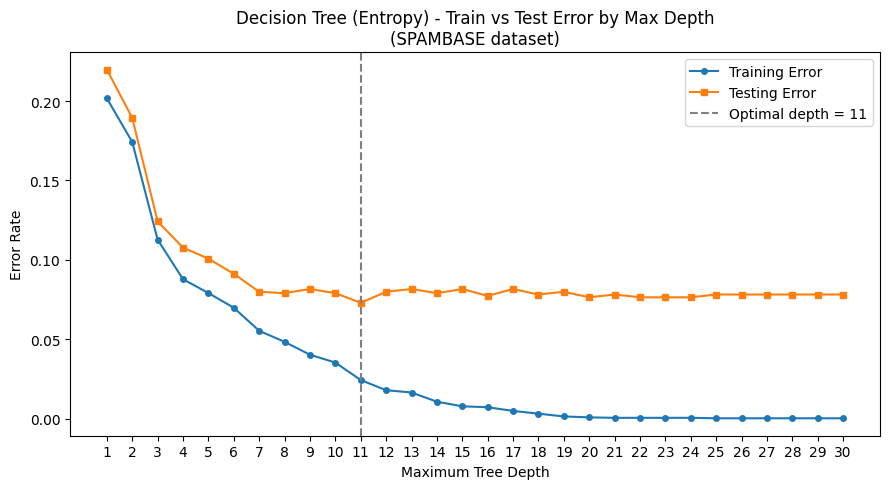

Plot saved to depth_vs_error.png


In [10]:
# Part 3 Depth limited pruning
depths = range(1,31)
train_errs = []
test_errs = []

for d in depths:
    clf = DecisionTreeClassifier(criterion="entropy", max_depth=d, random_state=42)
    clf.fit(x_tr, y_tr)
    train_errs.append(1 - accuracy_score(y_tr, clf.predict(x_tr)))
    test_errs.append(1 - accuracy_score(y_te, clf.predict(x_te)))

best_depth = depths[np.argmin(test_errs)]
print(f"Part 3 Optimal depth (lowest test error): {best_depth}")
print(f"    Test error at depth {best_depth}: {min(test_errs):.4f}\n")

# Plot
plt.figure(figsize=(9, 5))
plt.plot(depths, train_errs, marker="o", markersize=4, label="Training Error")
plt.plot(depths, test_errs, marker="s", markersize=4, label="Testing Error")
plt.axvline(best_depth, color="gray", linestyle="--",
            label=f"Optimal depth = {best_depth}")
plt.xlabel("Maximum Tree Depth")
plt.ylabel("Error Rate")
plt.title("Decision Tree (Entropy) - Train vs Test Error by Max Depth\n(SPAMBASE dataset)")
plt.legend()
plt.xticks(list(depths))
plt.tight_layout()
plt.savefig("depth_vs_error.png", dpi=150)
plt.show()
print("Plot saved to depth_vs_error.png")


# Observations for part 3
- The optimal depth for maximum tree depth is 11, and yeilds a test error of 0.0730
- The training error monotonically decreases as depth increases while the teast error follows a u shape reaching a min at depth 11 plateauing at larger depths